# Конструирование алгоритмов LSCP для плагина Генезис

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.2.301


Версии библиотек в QGIS:

    osmnx: 2.0.1
    networkx: 3.3
    pandas: 2.2.2
    geopandas: 1.0.1
    genesis: 0.2.201

## Загрузка данных

In [ ]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


map_path = 'G:/QGIS/Кемерово/'

# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml(map_path+'data/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ города
borders = gpd.read_file(map_path+'data/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file(map_path+'data/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file(map_path+'data/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

In [ ]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
buildings.plot(ax=ax, facecolor='deepskyblue', zorder=3)
units.plot(ax=ax, facecolor='red', edgecolor='k', alpha=0.9, zorder=4)
borders.boundary.plot(ax=ax, color='red', zorder=5, linewidth=0.5)
ax.legend()
ax.set_title('Граф дорог, здания и подразделения')

plt.show()

## Смесь Генезис + Итеративный поиск

In [ ]:
from genesis.best_points import BestNodeCircleZoom
from genesis.mclp import BestNodesKoptG
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.point_selectors import GenesisNodeSelector, FarNodeSelector
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка и инициализация алгоритма
# 2.1 Конструирвоание алгоритма поиска лучшего узла
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Выбор функции определения лучшего узла
blp_function = BestNodeCircleZoom(
    state_function    = state,
    metric_function   = metric,
    n_samples         = 10,
    n_min_count       = 5,
    step_end_function = None,
)


# 2.2 Конструирвоание алгоритма поиска множества лучших узлов
## MCLP функция
mclp_function = BestNodesKoptG(
    state_function              = state,
    metric_function             = metric,
    best_point_function         = blp_function,
    iterations                  = 5,
    appr_val_in_area            = 0,
    before_iters_start_function = None,
    iter_calc_end_function      = None,
    stop_case_function          = None,
)


# 2.3 Конструирвоание алгоритма определения требуемого количества лучшихузлов
## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-10 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Выбор функции выбора точек
point_selector_function = GenesisNodeSelector(
    state_function  = state,
    metric_function = metric,
    appr_val        = 0.95,
    weight          = 'travel_time',
)
point_selector_function = FarNodeSelector(
    state_function  = state,
    appr_val        = 0.95,
    weight          = 'travel_time',
)

## Сборка и инициализация алгоритма ADD
lscp = LSCPCommon(  
    mclp_function       = mclp_function,
    point_selector      = point_selector_function,
    stop_case_function  = stop_case,
    metric_function     = metric,
    after_mclp_function = after_mclp,
)



start_units_dict = {
    list(G.nodes())[0]: 'ПЧ-1',
}

# 3. Расчет
best_nodes, best_metric = lscp(
        env           = G,
        dynamic_nodes = start_units_dict,
    )

# 3.2 Печать промежуточных результатов
print('ПРЕДВАРИТЕЛЬНО:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

# 3.3 Проверка на избыточность
best_nodes, best_metric = drop_trash_points(
    env = G,
    state_function = state,
    metric_function = metric,
    stop_case_function = stop_case,
    dynamic_nodes = best_nodes,
)




# 4. Печать итоговых результатов
print('ИТОГ:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

## Смесь Генезис + (Скалолаз + центр диаметра)

In [ ]:
# from genesis.best_points import BestNodeCircleZoom
from fire_units.best_points import BestNodeHillClimbingHD
from genesis.mclp import BestNodesKoptG
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.point_selectors import GenesisNodeSelector, FarNodeSelector
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка и инициализация алгоритма
# 2.1 Конструирвоание алгоритма поиска лучшего узла
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Выбор функции определения лучшего узла
blp_function = BestNodeHillClimbingHD(
    state_function  = state,
    metric_function = metric,
)


# 2.2 Конструирвоание алгоритма поиска множества лучших узлов
## MCLP функция
mclp_function = BestNodesKoptG(
    state_function              = state,
    metric_function             = metric,
    best_point_function         = blp_function,
    iterations                  = 5,
    appr_val_in_area            = 0,
    before_iters_start_function = None,
    iter_calc_end_function      = None,
    stop_case_function          = None,
)


# 2.3 Конструирвоание алгоритма определения требуемого количества лучшихузлов
## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-10 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Выбор функции выбора точек
point_selector_function = GenesisNodeSelector(
    state_function  = state,
    metric_function = metric,
    appr_val        = 0.95,
    weight          = 'travel_time',
)
point_selector_function = FarNodeSelector(
    state_function  = state,
    appr_val        = 0.95,
    weight          = 'travel_time',
)

## Сборка и инициализация алгоритма ADD
lscp = LSCPCommon(  
    mclp_function       = mclp_function,
    point_selector      = point_selector_function,
    stop_case_function  = stop_case,
    metric_function     = metric,
    after_mclp_function = after_mclp,
)



start_units_dict = {
    list(G.nodes())[0]: 'ПЧ-1',
}

# 3. Расчет
best_nodes, best_metric = lscp(
        env           = G,
        dynamic_nodes = start_units_dict,
    )

# 3.2 Печать промежуточных результатов
print('ПРЕДВАРИТЕЛЬНО:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

# 3.3 Проверка на избыточность
best_nodes, best_metric = drop_trash_points(
    env = G,
    state_function = state,
    metric_function = metric,
    stop_case_function = stop_case,
    dynamic_nodes = best_nodes,
)




# 4. Печать итоговых результатов
print('ИТОГ:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

## Эталон: Жадное добавление

Расет матрицы прибытия

In [20]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 # data_sample_size = 4000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


Собственно расчет алгоритма

Подразделений: 1  ИП-10: 30.70744680851064
Подразделений: 2  ИП-10: 54.44946808510638
Подразделений: 3  ИП-10: 62.875
Подразделений: 4  ИП-10: 69.65425531914893
Подразделений: 5  ИП-10: 76.39095744680851
Подразделений: 6  ИП-10: 81.84042553191489
Подразделений: 7  ИП-10: 86.60372340425532
Подразделений: 8  ИП-10: 89.01595744680851
Подразделений: 9  ИП-10: 91.41489361702128
Подразделений: 10  ИП-10: 93.43882978723404
Подразделений: 11  ИП-10: 94.66755319148936
Подразделений: 12  ИП-10: 95.76329787234043
ИТОГ:
Подразделений: 12  ИП-10: 95.76329787234043


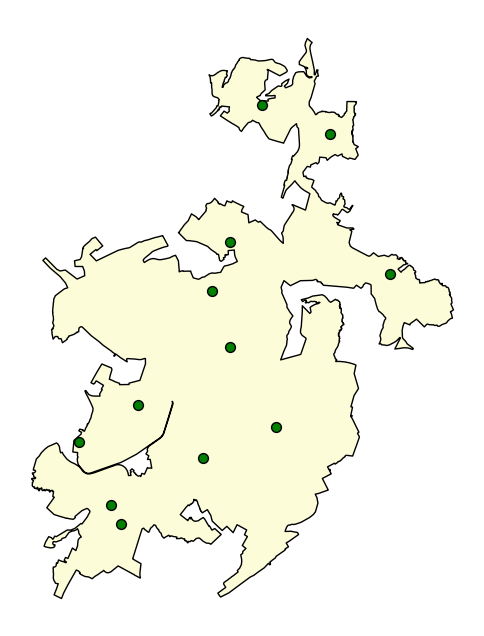

In [21]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка и инициализация алгоритма
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-10 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
    after_mclp_function = after_mclp,
)


# 3. Расчет
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
print('ИТОГ:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()